In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the cleaned dataset
df = pd.read_csv('new_cleaned_data.csv')
df

In [ ]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]                # removing unnamed column
df

In [ ]:
#distibrution of car price
plt.figure(figsize=(10,5))
sns.histplot(df['Price'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Car Prices')
plt.xlabel('Price (INR)')
plt.ylabel('Frequency')
plt.show()

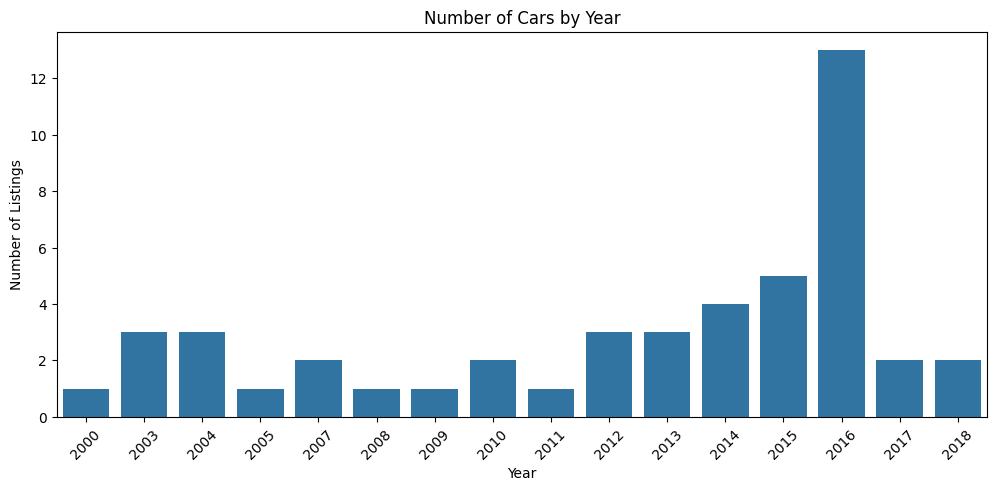

In [9]:
#car manufactring year
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='year', order=sorted(df['year'].unique()))
plt.xticks(rotation=45)
plt.title('Number of Cars by Year')
plt.xlabel('Year')
plt.ylabel('Number of Listings')
plt.show()

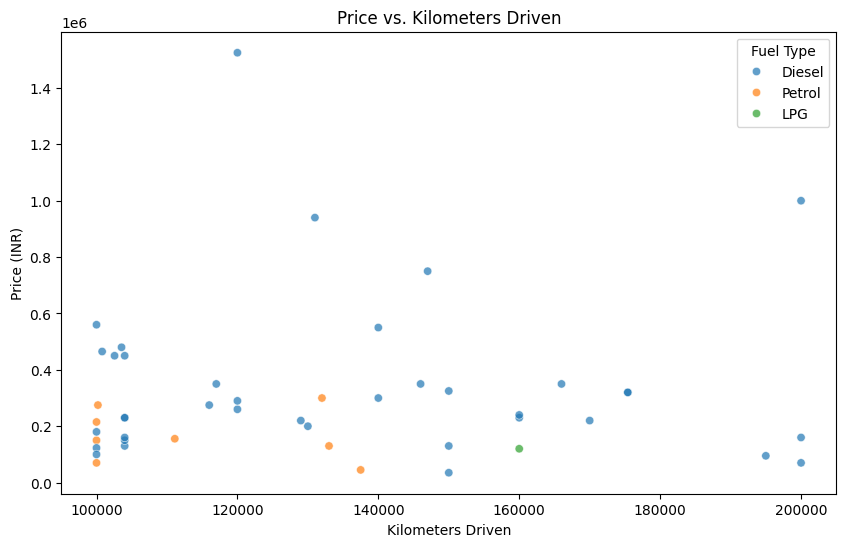

In [10]:
#kms driven vs price
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='kms_driven', y='Price', hue='fuel_type', alpha=0.7)
plt.title('Price vs. Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Price (INR)')
plt.legend(title='Fuel Type')
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_9052\232304215.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.index, y=top_brands.values, palette='viridis')


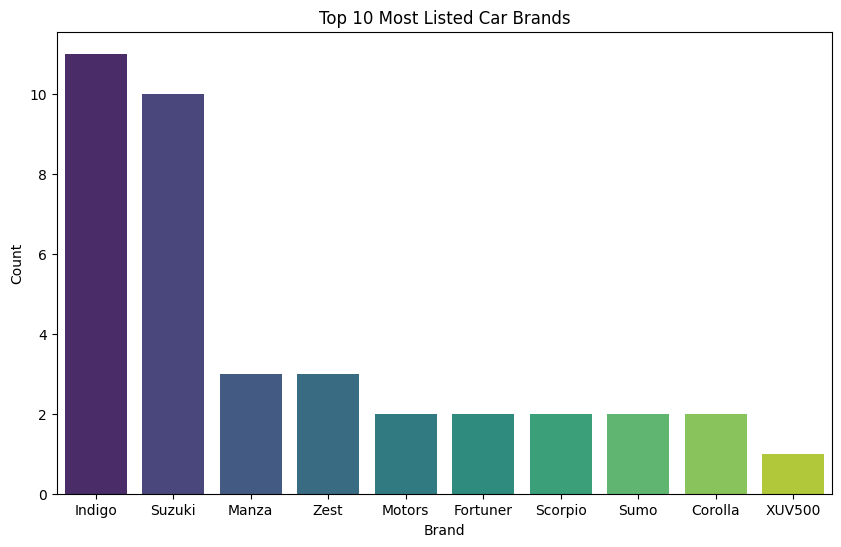

In [8]:
# Top 10 Most Listed Car Brands
df['brand'] = df['name'].str.split().str[0]  # Extract brand

top_brands = df['brand'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_brands.index, y=top_brands.values, palette='viridis')
plt.title('Top 10 Most Listed Car Brands')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_9052\2472564608.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['brand'].isin(top5)], x='brand', y='Price', palette='pastel')


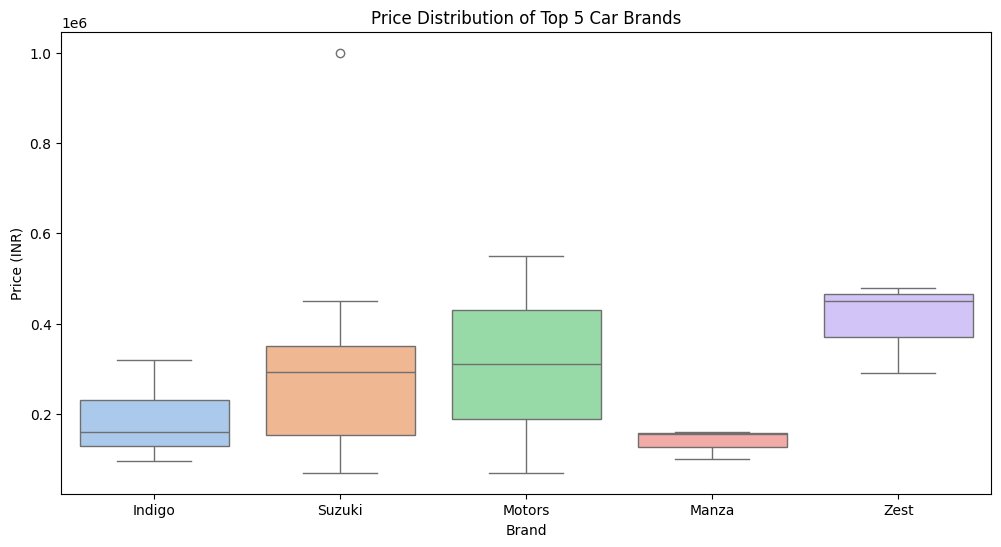

In [11]:
# Price Comparison of Top Brands (Boxplot)
top5 = df['brand'].value_counts().head(5).index
plt.figure(figsize=(12,6))
sns.boxplot(data=df[df['brand'].isin(top5)], x='brand', y='Price', palette='pastel')
plt.title('Price Distribution of Top 5 Car Brands')
plt.xlabel('Brand')
plt.ylabel('Price (INR)')
plt.show()

In [12]:
 Interpretation:
 
This shows the price range and outliers per brand. Some brands have higher price variability.
Santro targets the lower-budget segment.
City and Scorpio Brand attract premium buyyers, these brands may have more models/variants.

IndentationError: unexpected indent (3776721926.py, line 1)

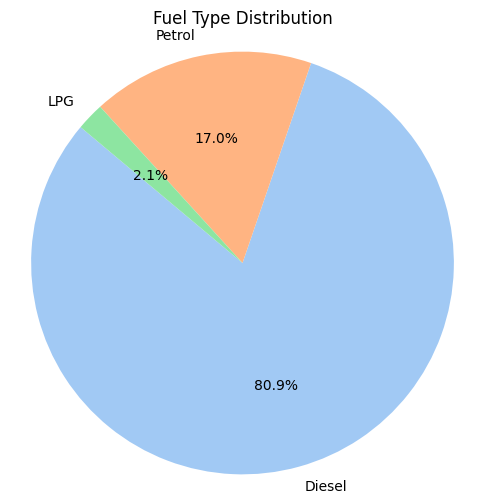

In [13]:
# fule type distibution
fuel_counts = df['fuel_type'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(fuel_counts, labels=fuel_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Fuel Type Distribution')
plt.axis('equal')  # Equal aspect ratio
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_9052\3794235637.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='fuel_type', y='Price', estimator='mean', palette='Accent')


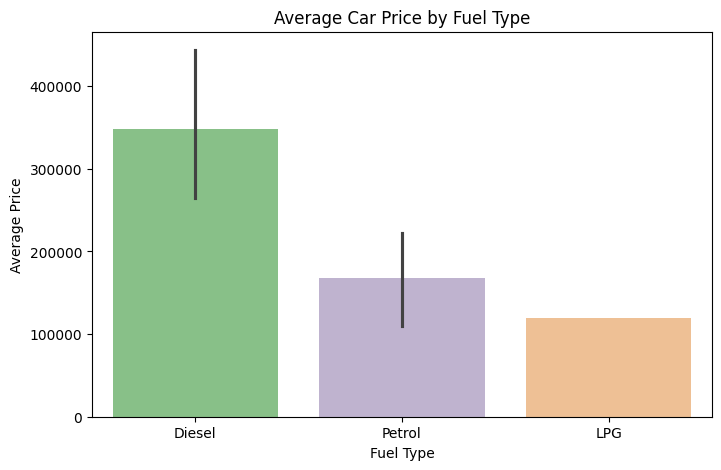

In [14]:
# Average Price by Fuel Type
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='fuel_type', y='Price', estimator='mean', palette='Accent')
plt.title('Average Car Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Price')
plt.show()

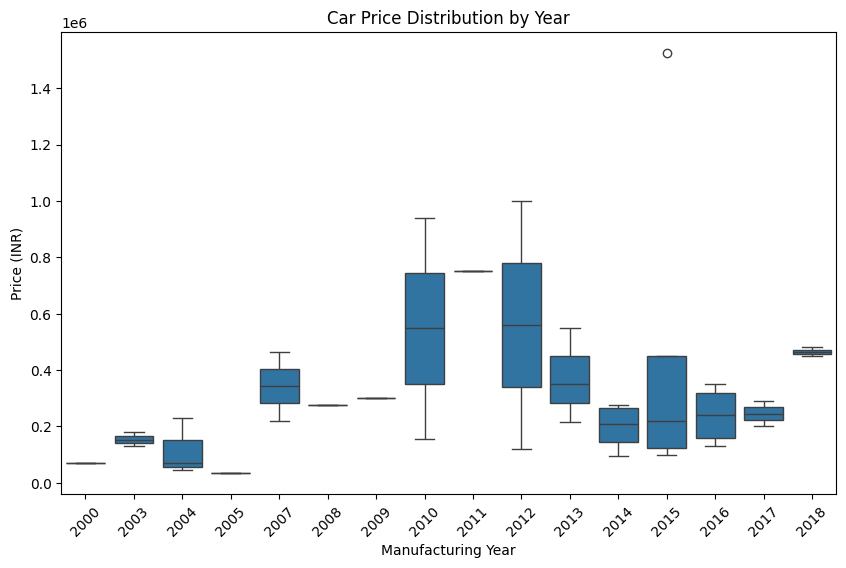

In [16]:

## Relationship Between Year and Price
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='year', y='Price')
plt.xticks(rotation=45)
plt.title('Car Price Distribution by Year')
plt.xlabel('Manufacturing Year')
plt.ylabel('Price (INR)')
plt.show()

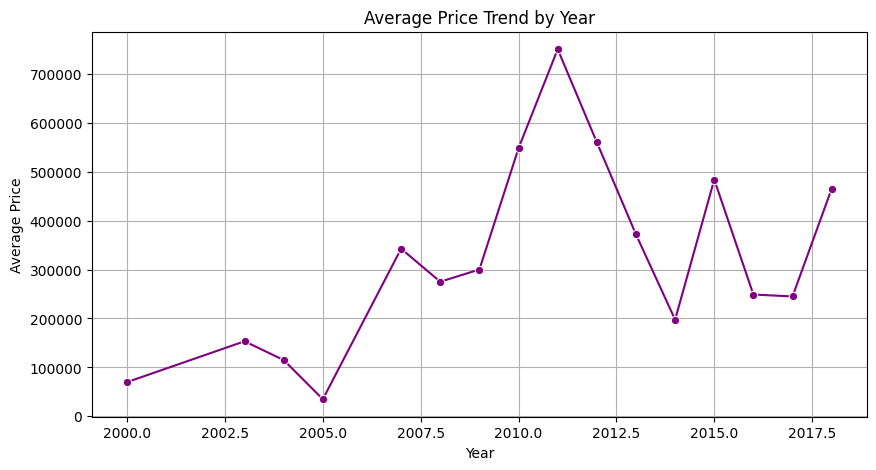

In [17]:
# Price Trend Over Years (Mean Price per Year)
avg_price_by_year = df.groupby('year')['Price'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=avg_price_by_year, x='year', y='Price', marker='o', color='purple')
plt.title('Average Price Trend by Year')
plt.xlabel('Year')
plt.ylabel('Average Price')
plt.grid(True)
plt.show()

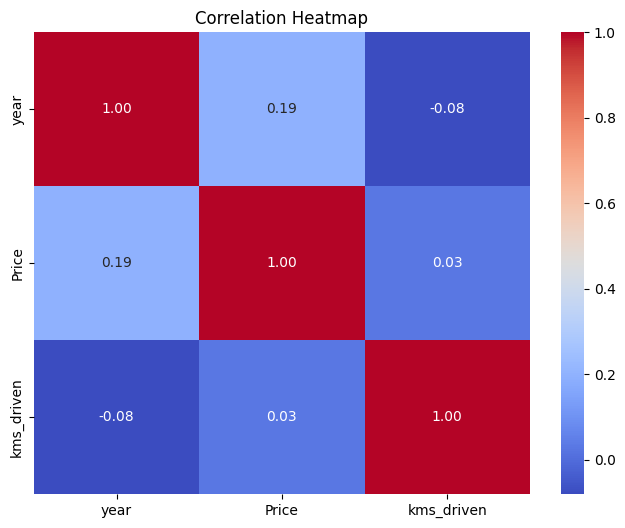

In [18]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
numeric_cols = df.select_dtypes(include='number')
corr_matrix = numeric_cols.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()